<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/06_denoising_introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install astrodendro
!pip install sep

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm
import astrodendro
from astrodendro import Dendrogram
from astrodendro.analysis import pp_catalog
from astropy.io import fits
from astropy import units as u
from importlib.metadata import metadata
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

Image loaded successfully.


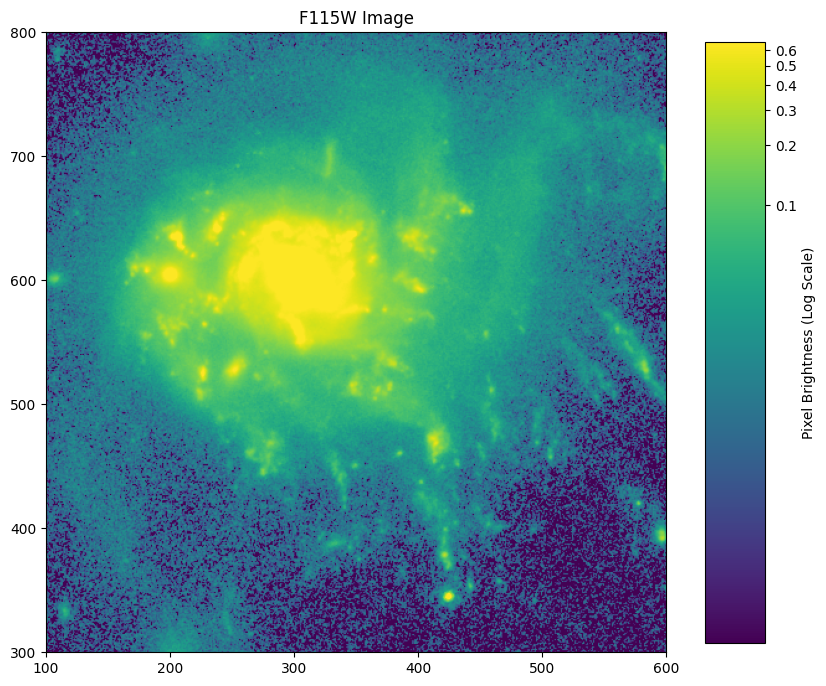

In [3]:


fits_file = '/content/F115W.fits'

try:
    with fits.open(fits_file) as hdul:

        raw_data = hdul[0].data
        image_data = raw_data.astype(float)

        print("Image loaded successfully.")

        # This first creates a mask to identify and ignore "bad" pixels (NaNs or zeros).
        good_pixel_mask = ~np.logical_or(np.isnan(image_data), image_data <= 0)

        # Then, it calculates the log stretch based ONLY on the good pixels.
        norm = simple_norm(image_data[good_pixel_mask], stretch='log', percent=98.5)

        # Display the image.
        fig, axes = plt.subplots(figsize=(10, 10))
        im = axes.imshow(image_data, cmap='viridis', origin='lower', norm=norm)
        fig.colorbar(im, label="Pixel Brightness (Log Scale)", shrink=0.78, aspect=10)
        axes.set_title("F115W Image")

        axes.set_xlim(100,600)
        axes.set_ylim(300,800)

        plt.show()

except FileNotFoundError:
    print(f"ERROR: File '{fits_file}' not found. Please ensure it is uploaded.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [4]:
dendo = Dendrogram.compute(image_data,
                   min_value = 0.06,
                   min_delta= 0.01,
                   min_npix=10)

num_structures = len(dendo)
num_leaves = len(dendo.leaves)
print(f"Number of structures: {num_structures}")
print(f"Number of leaves: {num_leaves}")

Number of structures: 337
Number of leaves: 193


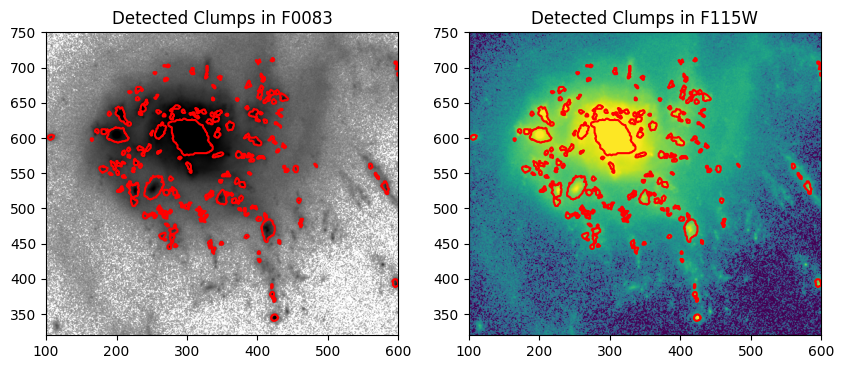

In [5]:
leaves = dendo.leaves
p = dendo.plotter()

fig, ax = plt.subplots(1,2, figsize=(10, 10))

good_pixel_mask = ~np.logical_or(np.isnan(image_data), image_data <= 0)
norm = simple_norm(image_data[good_pixel_mask], stretch='log', percent=98.5)
image1 = ax[0].imshow(image_data, cmap='gray_r', origin='lower', norm=norm)
image2 = ax[1].imshow(image_data, cmap='viridis', origin='lower',norm=norm)




for axes in ax:
    axes.set_xlim(100,600)
    axes.set_ylim(320,750)


for clump in leaves:
    p.plot_contour(ax[0], structure=clump, colors='red')
    p.plot_contour(ax[1], structure=clump, colors='red')
ax[0].set_title("Detected Clumps in F0083")
ax[1].set_title("Detected Clumps in F115W")
plt.show()

# Median Filtering

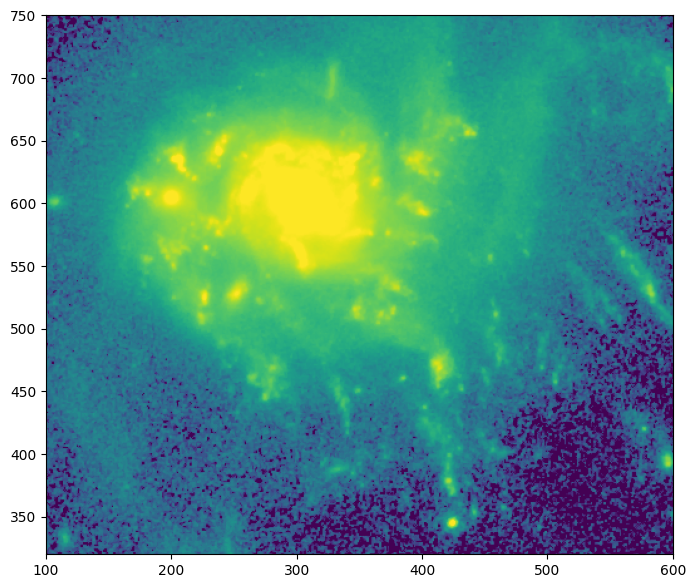

In [6]:
from skimage.filters import median
from skimage.morphology import disk

denoised_image = median(image_data,disk(1))

fig, ax = plt.subplots(figsize=(14, 7))

ax.set_xlim(100,600)
ax.set_ylim(320,750)
ax.imshow(denoised_image, cmap='viridis', origin='lower',norm=norm)

plt.show()


Assessment: Unsatisfactory. Barely any changes.

In [ ]:
!pip install sep

# Wavelet Denoising

Error during background subtraction: Input array with dtype `>f8` has non-native byte order. Only native byte order arrays are supported. To change the byte order of the array `data`, do `data = data.astype(data.dtype.newbyteorder('='))`
Applying wavelet denoising...
Image denoised successfully.


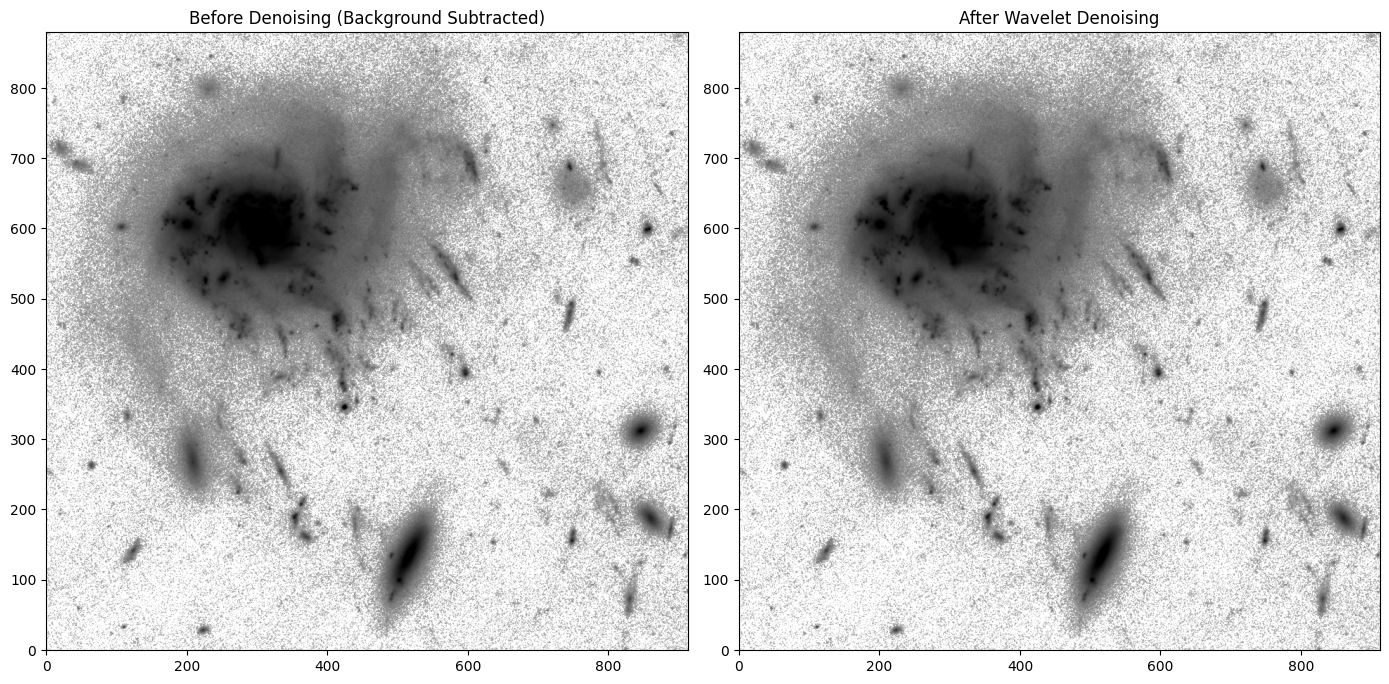

In [8]:
import sep
from skimage.restoration import denoise_wavelet

try:
    image_data_for_sep = image_data.view(image_data.dtype.newbyteorder())
    bkg = sep.Background(image_data_for_sep)
    image_noBackground = image_data - bkg.back()

    # This is our noise estimate for the denoising algorithm
    noise_sigma = bkg.globalrms

    print(f"Background subtracted. Estimated noise (sigma): {noise_sigma:.4f}")

except Exception as e:
    print(f"Error during background subtraction: {e}")
    # As a fallback if sep fails, but this is less accurate
    image_noBackground = image_data
    noise_sigma = np.nanstd(image_noBackground[image_noBackground < np.nanpercentile(image_noBackground, 10)])
    print(f"Warning: SEP failed. Using cruder noise estimate: {noise_sigma:.4f}")


print("Applying wavelet denoising...")

image_denoised = denoise_wavelet(image_noBackground,
                                 sigma=noise_sigma,
                                 wavelet='sym8')

print("Image denoised successfully.")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image_noBackground, cmap='gray_r', origin='lower', norm=norm)
axes[0].set_title("Before Denoising (Background Subtracted)")

axes[1].imshow(image_denoised, cmap='gray_r', origin='lower', norm=norm)
axes[1].set_title("After Wavelet Denoising")

plt.tight_layout()
plt.show()

Assessment: Same/slightly worse than just SEP background removal.

# Bilateral Filtering

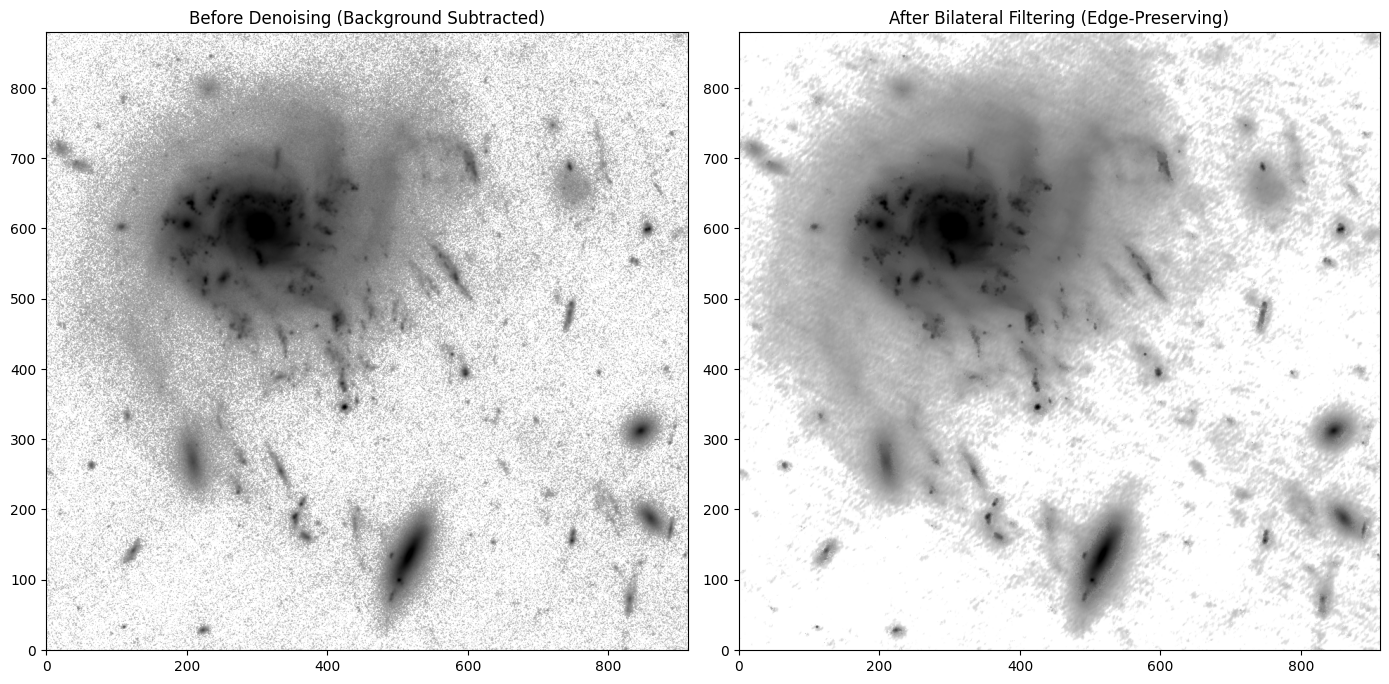

In [9]:
from skimage.restoration import denoise_bilateral

image_bilateral = denoise_bilateral(image_noBackground,
                                    sigma_color= noise_sigma*3,
                                    sigma_spatial=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
good_pixel_mask = ~np.logical_or(np.isnan(image_noBackground), image_noBackground <= 0)
norm = simple_norm(image_noBackground[good_pixel_mask], stretch='log', percent=99.5)

axes[0].imshow(image_noBackground, cmap='gray_r', origin='lower', norm=norm)
axes[0].set_title("Before Denoising (Background Subtracted)")

axes[1].imshow(image_bilateral, cmap='gray_r', origin='lower', norm=norm)
axes[1].set_title("After Bilateral Filtering (Edge-Preserving)")

plt.tight_layout()
plt.show()


Assessment: Visibly worse.

# White Top-Hat



Top-Hat transform applied.


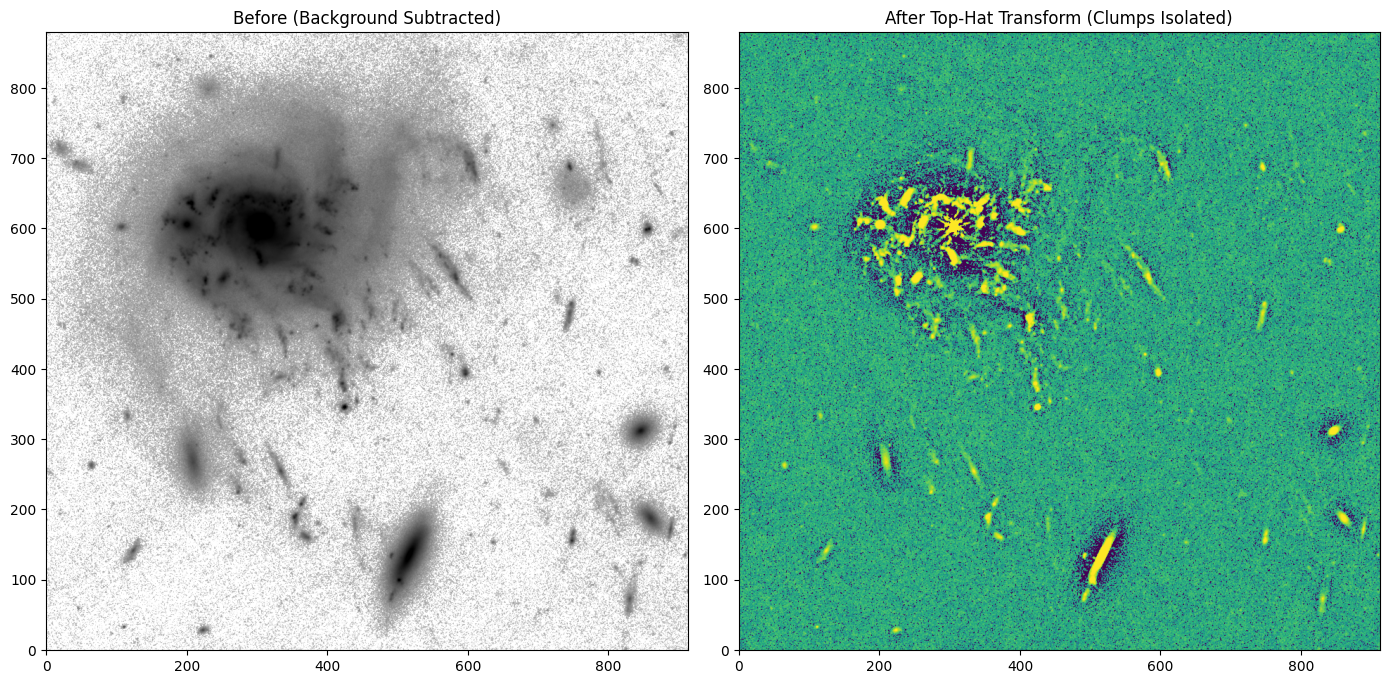

In [10]:
from skimage.morphology import white_tophat, disk

footprint = disk(7)

# Apply the transform
image_tophat = white_tophat(image_noBackground, footprint)

print("Top-Hat transform applied.")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

good_pixel_mask_orig = ~np.logical_or(np.isnan(image_noBackground), image_noBackground <= 0)
norm_orig = simple_norm(image_noBackground[good_pixel_mask_orig], stretch='log', percent=99.5)

good_pixel_mask_tophat = ~np.logical_or(np.isnan(image_tophat), image_tophat <= 0)
norm_tophat = simple_norm(image_tophat[good_pixel_mask_tophat], stretch='log', percent=99)

axes[0].imshow(image_noBackground, cmap='gray_r', origin='lower', norm=norm_orig)
axes[0].set_title("Before (Background Subtracted)")

axes[1].imshow(image_tophat, cmap='viridis', origin='lower', norm=norm_tophat)
axes[1].set_title("After Top-Hat Transform (Clumps Isolated)")

plt.tight_layout()
plt.show()

Assessment: Does not work well with the dendrogram (found 1889 clumps in the top-hat image)

All options so far proved unsatisfactory.